### The Hebbian and Anti-Hebbian Neural Network, 2 layers

The new network will have two parts:
- In their first layer, the neurons will be connected with a weight matrix \( W \) between output neurons \( y \) and input neurons \( x \).
$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$
- In their second layer, the output neurons \( y \) will conduct inhibition using between each other with a weight matrix \( V \).
$$
\mathbf{y = Wx + Vy \in \mathbb{R}^m}
$$

The first layer is a Hebbian network, while the second layer is an Anti-Hebbian network.
The equation to update the weights $\mathbf{W}$ is the same as the Hebbian network, while the equation to update the weights $\mathbf{V}$ is the same as the Anti-Hebbian network.

For symmetric, Oja's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = - \gamma (yy^T)}
$$

For asymmetric, Sanger's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = \gamma (yy^T - y^2 V_B), V_B = tril(V)}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork
import hebbian.utils as utils
from typing import Any, Optional

### Model structure

In [2]:
class antiHebbianModel(HebbianModel):
    """
    Two-layer Hebbian / anti-Hebbian network with optional activity-dependent lateral learning.

    rule:
      - "activity_sym"     : ΔV = ε_w (a_i + a_j) ⊙ V  - ε_v yy^T (symmetric)
    """
    def __init__(
        self,
        output_size: int,
        learning_rate = 0.01,
        learning_rate2 = None,
        eps_w: float = 0.01,
        eps_v: float = 0.03,             # γ or ε_v  (anti-Hebbian strength)
        rng: Optional[Any] = None,
        lateral_init: str = "random",
        zero_diagonal: bool = True,
        num_iteration: int = 100,
        tol: float = 1e-6,
        tau_activity: float = 1000.0,      # time constant for activity trace
        ) -> None:
        super().__init__(output_size, learning_rate, learning_rate2, rng)

        # Lateral weights V
        if lateral_init == "random":
            self.V = 0.001 * self.rng.standard_normal((self.output_size, self.output_size))
        elif lateral_init == "zeros":
            self.V = np.zeros((self.output_size, self.output_size), dtype=float)
        else:
            raise ValueError("lateral_init must be 'zeros' or 'random'")

        # Activity trace a_j ≈ E[y_j^2]
        self.activity_alpha =  1.0 - np.exp(-1.0 / max(1.0, float(tau_activity)))
        self.eps_w = float(eps_w)
        self.eps_v = float(eps_v)
        self.a = np.zeros(self.output_size, dtype=float)
        self.zero_diagonal = bool(zero_diagonal)
        self.num_iteration = num_iteration
        self.tol = tol

    def forward(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float).reshape(-1)
        # make sure the input size is set
        if self.input_size is None:
            self.input_size = x.shape[0]
            # Initialize weights if not already done
            self.W = 0.001 * self.rng.standard_normal((self.output_size, self.input_size))
        elif x.shape[0] != self.input_size:
            raise ValueError(f"Input dimension {x.shape[0]} does not match model input size {self.input_size}")
        # get the feedforward output
        Wx = self.W @ x.T
        # for a single data input entry, do iterations to make sure the output is converged
        y = Wx.copy()
        for _ in range(self.num_iteration):
            y_new = Wx + self.V @ y
            if np.linalg.norm(y_new - y) < self.tol:
                break
            y = y_new
        return y

    def step(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=float).reshape(-1)
        y = self.forward(x)
        # only update the diagonal of the weight matrix
        diag_y = np.diag(y**2)
        yyT = np.outer(y, y)
        # --- W update (multi-neuron Oja; same for all modes) ---
        self.W += self.learning_rate * np.outer(y, x) - self.learning_rate2 * diag_y @ self.W # A trick!!!! To use full Oja's rule instead of only diagonal matrix. 
        # --- Update activity trace a_j ≈ E[y_j^2] (EMA) ---
        self.a = (1.0 - self.activity_alpha) * self.a + self.activity_alpha * (y**2)
        # make sure diagonal is zero

        if self.zero_diagonal:
            yyT = yyT.copy()
            np.fill_diagonal(yyT, 0.0)
        # --- V updates ---
        # Activity-dependent leak:
        # ΔV = ε_w (a_i + a_j) * V  - ε_v y y^T
        A_sum = self.a[:, None] + self.a[None, :]            # (m,m)

        dV = self.eps_w * (A_sum * self.V) - self.eps_v * yyT
        self.V += dV
        # make sure again the diagonal is zero
        if self.zero_diagonal:
            np.fill_diagonal(self.V, 0.0)
        # make the matrix symmetric
        # self.V = 0.5 * (self.V + self.V.T)
        # make the matrix non-positive
        self.V = np.minimum(self.V, 0.0)
        return y

    def get_effective_weights(self):
        """
        Compute effective input->output mapping A = (I - V)^(-1) W.

        Parameters
        ----------
        W : ndarray, shape (m, p)
            Input-to-output weight matrix.
        V : ndarray, shape (m, m)
            Recurrent weight matrix.

        Returns
        -------
        A : ndarray, shape (m, p)
            Effective mapping from inputs to outputs.
        """
        m, n = self.W.shape
        I = np.eye(m)
        A = np.linalg.solve(I - self.V, self.W)  # safer than explicit inverse
        return A

### Test case 2D

In [3]:
mu1 = 0.0
std1 = 0.3
mu2 = 0.0
std2 = 0.9
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 200000

# hebbian strength
learning_rate = 0.001
learning_rate2 = 0.05
# eps_w 
eps_w = 0.0001
eps_v = 0.05

{'pcs': array([[ 0.7972046 , -0.60370922],
        [-0.60370922, -0.7972046 ]]),
 'eigvals': array([0.80939249, 0.08952921]),
 'mean': array([-2.99893443e-17,  1.46804791e-17])}

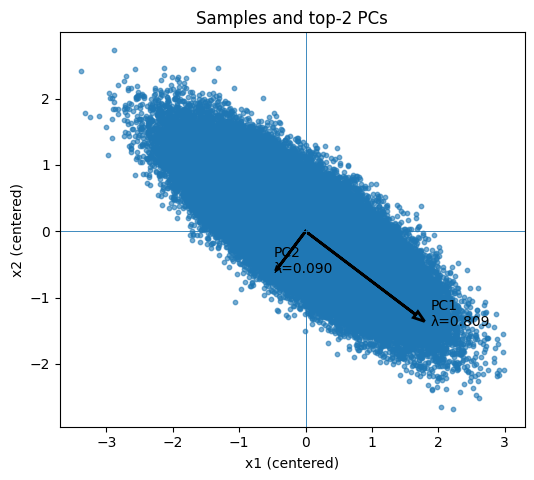

In [4]:
# generate 2D input data
samples_2d = utils.gauss_distrib(orientation, mu1, std1, mu2, std2, number_of_samples, number_of_neurons=2)
utils.plot_samples_and_top2_pcs(samples_2d)

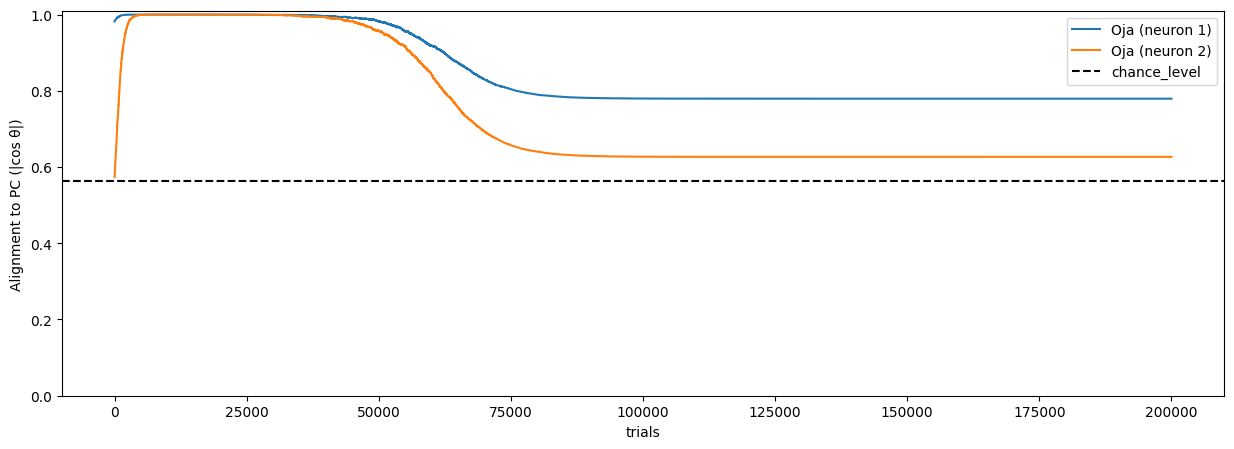

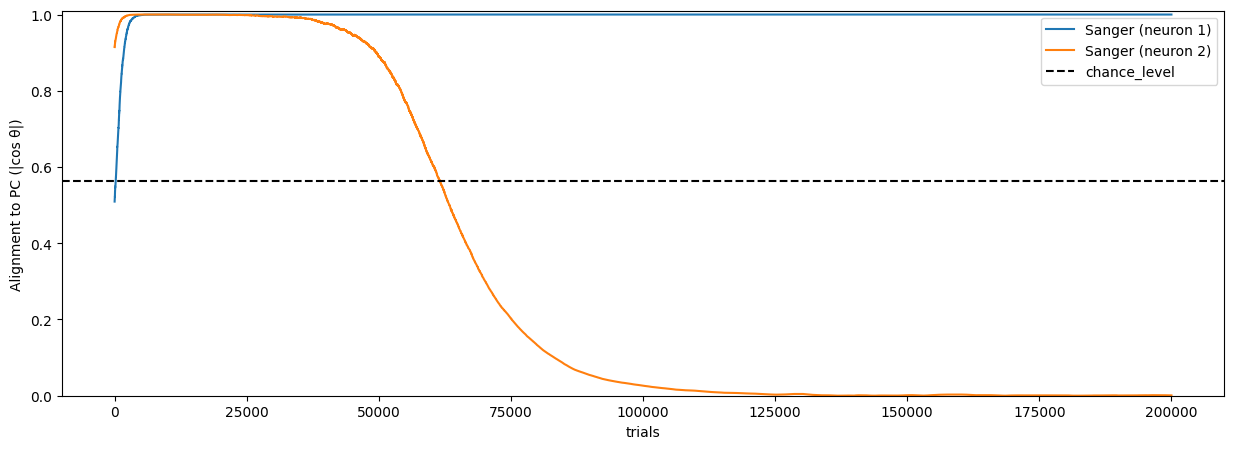

In [5]:
model1 = OjaNetwork(output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=2, learning_rate=learning_rate)

utils.training_testing(samples_2d, models = {"Oja": model1, "Sanger": model2}, output_size=2,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)


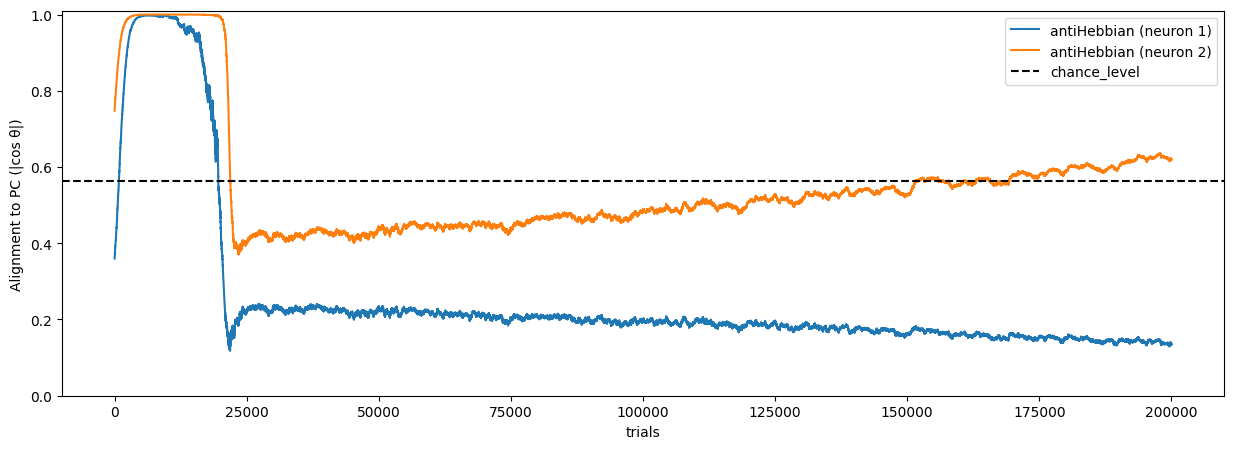

In [6]:
model = antiHebbianModel(output_size=2, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=eps_w, eps_v = eps_v)
utils.training_testing(samples_2d, models = {"antiHebbian": model}, output_size=2,
                            pc_method = "first", alignment_method = "weights",
                            show_num = None)

### Test case 3D

In [7]:
mu = np.array([0.0, 0.0, 0.0])   # means for 3 neurons
cov = np.array([[0.3, 0.2, 0.3],   # covariance matrix (3x3, symmetric, PSD)
                [0.2, 0.5, 0.8],
                [0.3, 0.8, 1.0]])
samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)

# Center the data (zero mean)
samples_3d -= samples_3d.mean(axis=0, keepdims=True)

/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_9252/4081760888.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


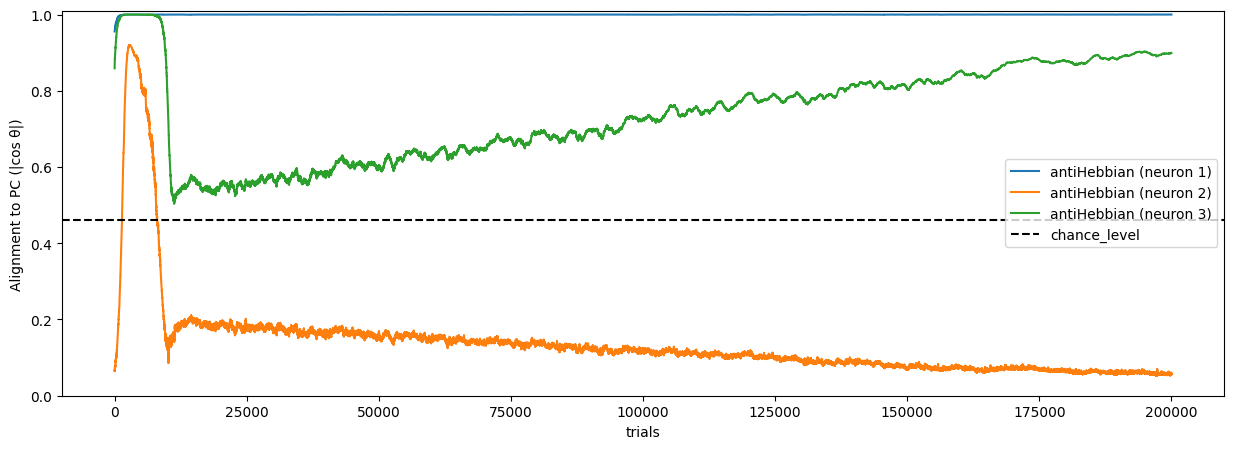

In [8]:
model = antiHebbianModel(output_size=3, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=eps_w, eps_v = eps_v)
utils.training_testing(samples_3d, models = {"antiHebbian": model}, output_size=3,
                          pc_method = "first", alignment_method = "weights",
                          show_num = None)

### Test case 10D

In [9]:
# 10-dimensional mean vector
mu = np.zeros(10)

# 10x10 covariance matrix (symmetric, PSD)
cov = np.array([
    [1.0, 0.8, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.8, 0.5, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.3, 0.2, 0.3, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
])

# sample data
samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_9252/2593445669.py:19: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


/Users/yat-lok/miniconda3/envs/nn/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_9252/3100401271.py:55: RuntimeWarning: overflow encountered in matmul
  y_new = Wx + self.V @ y
/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_9252/3100401271.py:55: RuntimeWarning: invalid value encountered in matmul
  y_new = Wx + self.V @ y


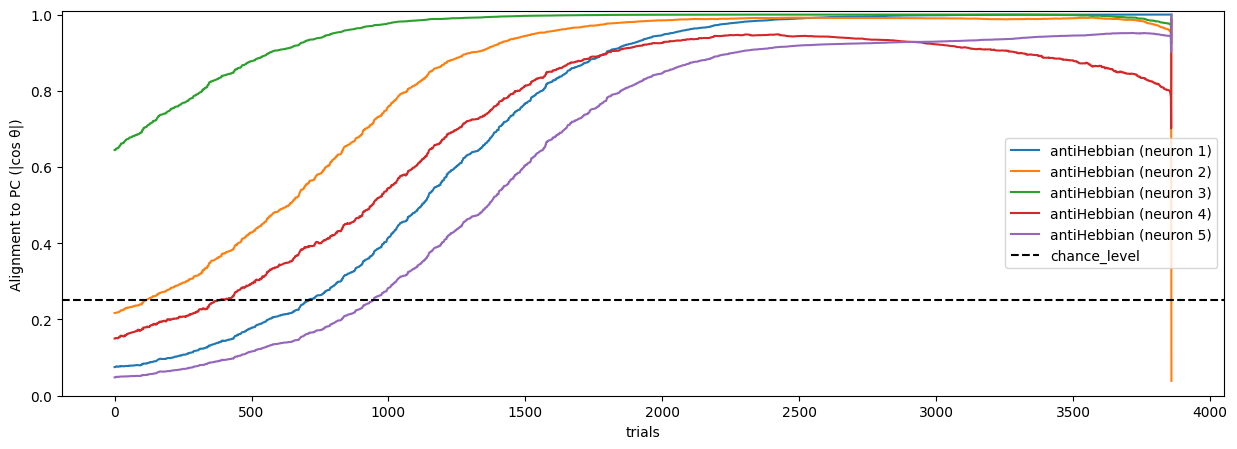

In [10]:
model = antiHebbianModel(output_size=5, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=-eps_w, eps_v=eps_v)
utils.training_testing(samples_10d, models = {"antiHebbian": model}, output_size=5,
                       pc_method = "first", alignment_method="weights",
                       show_num = None)